In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Step 1 Complete: All data science libraries loaded successfully!")

Step 1 Complete: All data science libraries loaded successfully!


In [2]:
# Load the dataset out of your Data folder
# (Make sure your file is renamed to dataset.csv inside your Data folder!)
df = pd.read_csv("../Data/dataset.csv")

# 1. Print out the structure size
print(f"Dataset Size: {df.shape[0]} rows and {df.shape[1]} columns.\n")

# 2. View the first 5 rows of data to see what it looks like
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../Data/dataset.csv'

In [3]:
import os

# Let's find out exactly what extension Windows is hiding
folder_path = "../Data/"
files = os.listdir(folder_path)
actual_file_name = files[0] # Grab the file inside Data
print(f"The actual file name Python sees is: {actual_file_name}")

# Now load it automatically based on its real name!
try:
    if actual_file_name.endswith('.xlsx') or actual_file_name.endswith('.xls'):
        df = pd.read_excel(f"../Data/{actual_file_name}")
    else:
        df = pd.read_csv(f"../Data/{actual_file_name}")
    
    print(f"Dataset loaded perfectly! Size: {df.shape[0]} rows, {df.shape[1]} columns.\n")
    display(df.head())
except Exception as e:
    print(f"Error loading file: {e}")

The actual file name Python sees is: dataset.csv.csv
Dataset loaded perfectly! Size: 114000 rows, 21 columns.



,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
# --- STEP 7 & 8: Check and Clean Missing Values ---
print("1. Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Shows only columns with missing data
print("-" * 50)

# Drop rows missing names or artists
df = df.dropna(subset=["track_name", "artists"])

# --- STEP 9: Remove Duplicates ---
print(f"2. Number of exact duplicate rows found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print("-" * 50)

# --- STEP 10: Feature Engineering (Convert Duration) ---
# duration_ms is in milliseconds. Let's make it minutes!
df["duration_min"] = (df["duration_ms"] / 60000).round(2)

print(f"3. Cleaning Complete! Final remaining dataset size: {df.shape[0]} rows.")
print("\nVerification of your new column:")
df[["track_name", "duration_ms", "duration_min"]].head()

1. Missing values before cleaning:
artists       1
album_name    1
track_name    1
dtype: int64
--------------------------------------------------
2. Number of exact duplicate rows found: 0
--------------------------------------------------
3. Cleaning Complete! Final remaining dataset size: 113999 rows.

Verification of your new column:


,track_name,duration_ms,duration_min
0,Comedy,230666,3.84
1,Ghost - Acoustic,149610,2.49
2,To Begin Again,210826,3.51
3,Can't Help Falling In Love,201933,3.37
4,Hold On,198853,3.31


--- Core Dataset Musical Averages ---


,popularity,danceability,energy,tempo,valence
mean,33.238827,0.566801,0.641383,122.147695,0.474066
min,0.000000,0.000000,0.000000,0.000000,0.000000
max,100.000000,0.985000,1.000000,243.372000,0.995000


------------------------------------------------------------


C:\Users\KIIT\AppData\Local\Temp\ipykernel_8636\4078067630.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette="viridis")


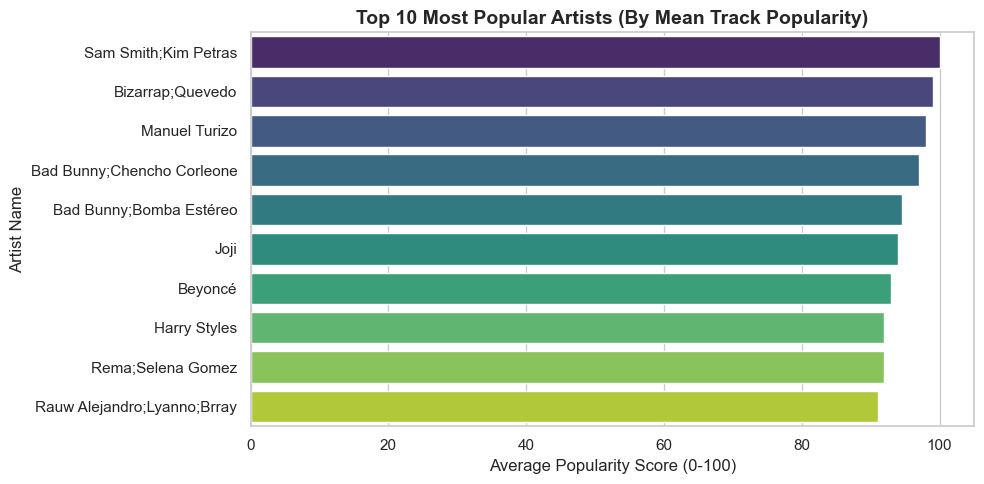


--- Top 10 Most Popular Genres ---
track_genre
pop-film     59.283000
k-pop        56.952953
chill        53.651000
sad          52.379000
grunge       49.594000
indian       49.539000
anime        48.772000
emo          48.128000
sertanejo    47.866000
pop          47.576000
Name: popularity, dtype: float64


In [5]:
# --- STEP 11: Descriptive Statistics for Core Audio Features ---
print("--- Core Dataset Musical Averages ---")
features = ["popularity", "danceability", "energy", "tempo", "valence"]
display(df[features].describe().loc[['mean', 'min', 'max']])
print("-" * 60)

# --- STEP 12: Identify and Plot Top 10 Most Popular Artists ---
# Group by artist, calculate their average popularity score, and take the top 10
top_artists = df.groupby("artists")["popularity"].mean().sort_values(ascending=False).head(10)

# Create a beautiful vertical bar chart using seaborn
plt.figure(figsize=(10, 5))
sns.barplot(x=top_artists.values, y=top_artists.index, palette="viridis")
plt.title("Top 10 Most Popular Artists (By Mean Track Popularity)", fontsize=14, fontweight='bold')
plt.xlabel("Average Popularity Score (0-100)", fontsize=12)
plt.ylabel("Artist Name", fontsize=12)
plt.tight_layout()
plt.show()

# --- STEP 13: Identify Top 10 Most Popular Genres ---
top_genres = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(10)
print("\n--- Top 10 Most Popular Genres ---")
print(top_genres)

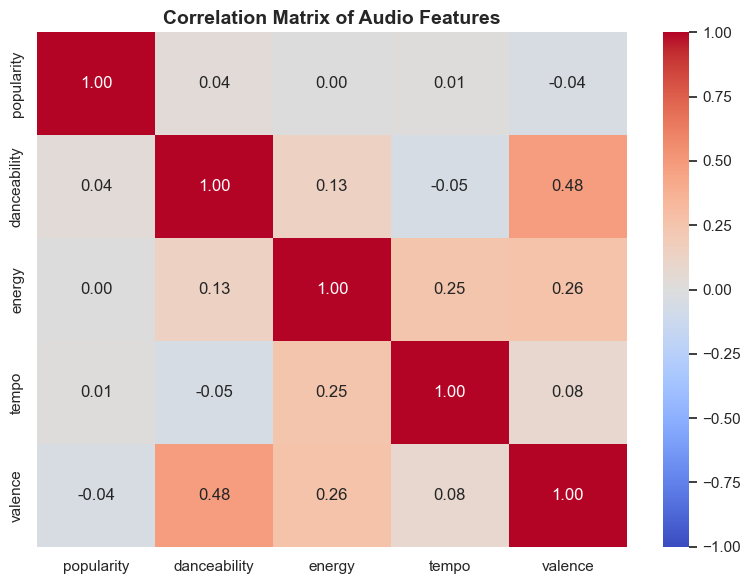


--- HYPOTHESIS TEST RESULTS ---
High Valence (Happy songs) Avg Popularity: 32.08
Low Valence (Sad/Serious songs) Avg Popularity: 34.21
Calculated p-value: 3.454747864793813e-58

Result: Significant difference found! Valence reliably impacts popularity.


In [6]:
# --- STEP 14 & 15: Correlation Matrix & Heatmap ---
features = ["popularity", "danceability", "energy", "tempo", "valence"]
corr = df[features].corr()

plt.figure(figsize=(8, 6))
# Annot=True prints the correlation numbers inside the squares
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Audio Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- STEP 16: Hypothesis Testing (Are happier songs more popular?) ---
# Valence tracks musical positiveness from 0.0 (sad) to 1.0 (happy)
from scipy.stats import ttest_ind

high_valence = df[df["valence"] > 0.5]["popularity"]
low_valence = df[df["valence"] <= 0.5]["popularity"]

t_stat, p_value = ttest_ind(high_valence, low_valence, equal_var=False)

print("\n" + "="*50)
print("--- HYPOTHESIS TEST RESULTS ---")
print(f"High Valence (Happy songs) Avg Popularity: {high_valence.mean():.2f}")
print(f"Low Valence (Sad/Serious songs) Avg Popularity: {low_valence.mean():.2f}")
print(f"Calculated p-value: {p_value}")

if p_value < 0.05:
    print("\nResult: Significant difference found! Valence reliably impacts popularity.")
else:
    print("\nResult: No significant difference found. Valence does not impact popularity.")
print("="*50)

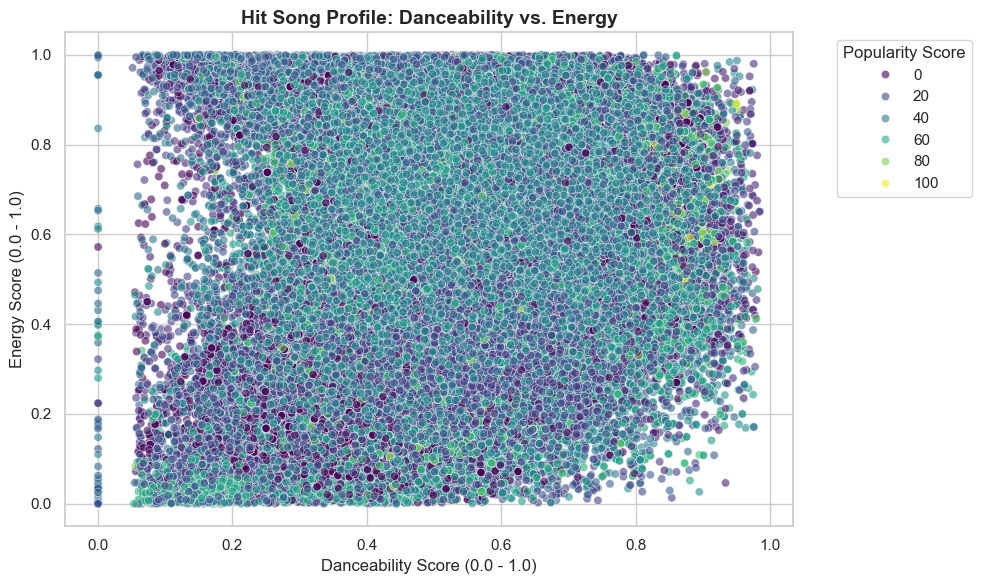

In [8]:
# --- STEP 17: Scatter Plot (The Hit Song Profile) ---
plt.figure(figsize=(10, 6))

# Creating a scatter plot to view structural audio patterns
sns.scatterplot(
    data=df,
    x="danceability",
    y="energy",
    hue="popularity",
    palette="viridis",
    alpha=0.6
)

plt.title("Hit Song Profile: Danceability vs. Energy", fontsize=14, fontweight='bold')
plt.xlabel("Danceability Score (0.0 - 1.0)", fontsize=12)
plt.ylabel("Energy Score (0.0 - 1.0)", fontsize=12)

# Move legend out of the way of data points
plt.legend(title="Popularity Score", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the image automatically to your project images folder for portfolio use!
plt.savefig("../Image/hit_song_profile.png", dpi=300)
plt.show()

In [9]:
# Save our beautifully cleaned data into a new file inside the Data folder
df.to_csv("../Data/cleaned_spotify_data.csv", index=False)
print("Cleaned dataset exported successfully!")

Cleaned dataset exported successfully!
